# Reliability-Aware Deep Learning Framework for Chemical Genotoxicity Prediction with Uncertainty Quantification

## Seul Lee, Jaeoh Kim*, Keunhong Jeong*

In [2]:
import tensorflow as tf
import tensorflow_probability as tfp
import tensorflow_addons as tfa
import numpy as np
import pandas as pd
from rdkit import Chem
from collections import namedtuple
import nfp
from nfp.preprocessing.mol_preprocessor import SmilesPreprocessor
from nfp.preprocessing.features import get_ring_size
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [3]:
# -------------------------------
#  Data preprocessing
# -------------------------------
atom_type = namedtuple('Atom', ['symbol', 'aromatic', 'ring_size', 'degree', 'totalHs'])
bond_type = namedtuple('Bond', ['bond_type', 'degree', 'ring_size'])

def atom_featurizer(atom):
    return atom_type(
        atom.GetSymbol(),
        atom.GetIsAromatic(),
        get_ring_size(atom, max_size=6),
        atom.GetDegree(),
        atom.GetTotalNumHs(includeNeighbors=True)
    )

def bond_featurizer(bond, flipped=False):
    btype = str(bond.GetBondType())
    ring = get_ring_size(bond, max_size=6) if bond.IsInRing() else None
    return bond_type(btype, bond.GetBondTypeAsDouble(), ring)

preprocessor = SmilesPreprocessor(
    atom_features=atom_featurizer,
    bond_features=bond_featurizer,
    explicit_hs=False
)

In [4]:
# data load
data_df = pd.read_csv('toxic.txt', sep='\t')

# Remove invalide SMILES
invalid_indices = []
for idx, s in data_df['SMILES'].iteritems():
    mol = Chem.MolFromSmiles(s)
    if mol is None:
        print(f"Warning: SMILES '{s}' is invalid and will be skipped.")
        invalid_indices.append(idx)
    else:
        preprocessor.construct_feature_matrices(s)
print(f"Total invalid SMILES removed: {len(invalid_indices)}")
data_df = data_df.drop(invalid_indices)

# Split data by group
median_data = data_df[data_df['group'] == 'mid'].copy()
low_data = data_df[data_df['group'] == 'low'].copy()
high_data = data_df[data_df['group'] == 'high'].copy()

# Assign initial sample weights
median_data['weight'] = 1.0
high_data['weight'] = 1.3

Total invalid SMILES removed: 7


In [8]:
#chk: table by group
pd.crosstab(data_df['group'], data_df['Judgment'])


Judgment,0,1
group,,
high,0,3
low,2113,1163
mid,2424,2686


In [9]:
# -------------------------------
# Hyperparameter and Generator Definition
# -------------------------------
EPOCHS = 20

In [10]:
# Define initial training data generator
def data_generator_with_actual_weight(df, preprocessor):
    for _, row in df.iterrows():
        try:
            features = preprocessor.construct_feature_matrices(row.SMILES)
            sample_input = {
                'atom': np.array(features['atom'], dtype=np.int32),
                'bond': np.array(features['bond'], dtype=np.int32),
                'connectivity': np.array(features['connectivity'], dtype=np.int32)
            }
        except Exception as e:
            print(f"Warning: Unable to process SMILES '{row.SMILES}': {e}. Using empty features.")
            sample_input = {
                'atom': np.empty((0,), dtype=np.int32),
                'bond': np.empty((0,), dtype=np.int32),
                'connectivity': np.empty((0, 2), dtype=np.int32)
            }
        yield (sample_input, float(row.Judgment), float(row['weight']))


# output signature for generators
output_sig = (
    {
        'atom': tf.TensorSpec(shape=(None,), dtype=tf.int32),
        'bond': tf.TensorSpec(shape=(None,), dtype=tf.int32),
        'connectivity': tf.TensorSpec(shape=(None, 2), dtype=tf.int32),
    },
    tf.TensorSpec(shape=(), dtype=tf.float32),  # label
    tf.TensorSpec(shape=(), dtype=tf.float32)   # weight
)

# -------------------------------
# # Define evaluation data generator (weights are not used during evaluation)
# -------------------------------
def data_generator_eval(df, preprocessor):
    for _, row in df.iterrows():
        try:
            features = preprocessor.construct_feature_matrices(row.SMILES)
            sample_input = {
                'atom': np.array(features['atom'], dtype=np.int32),
                'bond': np.array(features['bond'], dtype=np.int32),
                'connectivity': np.array(features['connectivity'], dtype=np.int32)
            }
        except Exception as e:
            print(f"Warning: Unable to process SMILES '{row.SMILES}': {e}. Using empty features.")
            sample_input = {
                'atom': np.empty((0,), dtype=np.int32),
                'bond': np.empty((0,), dtype=np.int32),
                'connectivity': np.empty((0, 2), dtype=np.int32)
            }
        yield (sample_input, float(row.Judgment))
        
# evaluation output signature
output_sig_eval = (
    {
        'atom': tf.TensorSpec(shape=(None,), dtype=tf.int32),
        'bond': tf.TensorSpec(shape=(None,), dtype=tf.int32),
        'connectivity': tf.TensorSpec(shape=(None, 2), dtype=tf.int32)
    },
    tf.TensorSpec(shape=(), dtype=tf.float32)
)

In [11]:
# Model architecture
def build_model(num_features, layers, learning_rate):
    # input layer
    atom_input = tf.keras.layers.Input(shape=(None,), dtype=tf.int32, name='atom')
    bond_input = tf.keras.layers.Input(shape=(None,), dtype=tf.int32, name='bond')
    connectivity_input = tf.keras.layers.Input(shape=(None, 2), dtype=tf.int32, name='connectivity')
    
    # embedding layer
    atom_state = tf.keras.layers.Embedding(preprocessor.atom_classes, num_features,
                                             name='atom_embedding', mask_zero=True)(atom_input)
    bond_state = tf.keras.layers.Embedding(preprocessor.bond_classes, num_features,
                                             name='bond_embedding', mask_zero=True)(bond_input)
    atom_mean = tf.keras.layers.Embedding(preprocessor.atom_classes, 1,
                                            name='atom_mean', mask_zero=True)(atom_input)
    
    # GNN
    for _ in range(layers):
        new_bond_state = nfp.EdgeUpdate()([atom_state, bond_state, connectivity_input])
        bond_state = tf.keras.layers.Add()([bond_state, new_bond_state])
    
        new_atom_state = nfp.NodeUpdate()([atom_state, bond_state, connectivity_input])
        atom_state = tf.keras.layers.Add()([atom_state, new_atom_state])
    
    atomwise_prediction = tf.keras.layers.Dense(1)(atom_state)
    atomwise_prediction = tf.keras.layers.Add()([atomwise_prediction, atom_mean])
    mol_prediction = tf.keras.layers.GlobalAveragePooling1D()(atomwise_prediction)
    output = tf.keras.layers.Activation('sigmoid')(mol_prediction)
    
    model = tf.keras.Model([atom_input, bond_input, connectivity_input], output)
    optimizer = tfa.optimizers.AdamW(learning_rate=learning_rate, weight_decay=1e-5)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [67]:
# -------------------------------
# Step 1: Hyperparameter tuning of the GNN using mid- and high-confidence samples
# -------------------------------
# Combine mid- and high-confidence data and perform train/validation split (for tuning)
mid_high_df = pd.concat([median_data, high_data], ignore_index=True)
train_mid_high_df, val_mid_high_df = train_test_split(mid_high_df, test_size=0.2, random_state=42, stratify=mid_high_df['Judgment'])

hp_sets_step1 = [
    {'num_features': 64, 'layers': 2, 'learning_rate': 1e-4, 'batch_size': 32},
    {'num_features': 64, 'layers': 2, 'learning_rate': 1e-4, 'batch_size': 64},
    {'num_features': 64, 'layers': 2, 'learning_rate': 5e-4, 'batch_size': 32},
    {'num_features': 64, 'layers': 2, 'learning_rate': 5e-4, 'batch_size': 64},
    {'num_features': 64, 'layers': 2, 'learning_rate': 5e-5, 'batch_size': 32},
    {'num_features': 64, 'layers': 2, 'learning_rate': 5e-5, 'batch_size': 64},
    {'num_features': 64, 'layers': 3, 'learning_rate': 1e-4, 'batch_size': 32},
    {'num_features': 64, 'layers': 3, 'learning_rate': 1e-4, 'batch_size': 64},
    {'num_features': 64, 'layers': 3, 'learning_rate': 5e-4, 'batch_size': 32},
    {'num_features': 64, 'layers': 3, 'learning_rate': 5e-4, 'batch_size': 64},
    {'num_features': 64, 'layers': 3, 'learning_rate': 5e-5, 'batch_size': 32},
    {'num_features': 64, 'layers': 3, 'learning_rate': 5e-5, 'batch_size': 64},
    {'num_features': 64, 'layers': 4, 'learning_rate': 1e-4, 'batch_size': 32},
    {'num_features': 64, 'layers': 4, 'learning_rate': 1e-4, 'batch_size': 64},
    {'num_features': 64, 'layers': 4, 'learning_rate': 5e-4, 'batch_size': 32},
    {'num_features': 64, 'layers': 4, 'learning_rate': 5e-4, 'batch_size': 64},
    {'num_features': 64, 'layers': 4, 'learning_rate': 5e-5, 'batch_size': 32},
    {'num_features': 64, 'layers': 4, 'learning_rate': 5e-5, 'batch_size': 64},
    {'num_features': 128, 'layers': 2, 'learning_rate': 1e-4, 'batch_size': 32},
    {'num_features': 128, 'layers': 2, 'learning_rate': 1e-4, 'batch_size': 64},
    {'num_features': 128, 'layers': 2, 'learning_rate': 5e-4, 'batch_size': 32},
    {'num_features': 128, 'layers': 2, 'learning_rate': 5e-4, 'batch_size': 64},
    {'num_features': 128, 'layers': 2, 'learning_rate': 5e-5, 'batch_size': 32},
    {'num_features': 128, 'layers': 2, 'learning_rate': 5e-5, 'batch_size': 64},
    {'num_features': 128, 'layers': 3, 'learning_rate': 1e-4, 'batch_size': 32},
    {'num_features': 128, 'layers': 3, 'learning_rate': 1e-4, 'batch_size': 64},
    {'num_features': 128, 'layers': 3, 'learning_rate': 5e-4, 'batch_size': 32},
    {'num_features': 128, 'layers': 3, 'learning_rate': 5e-4, 'batch_size': 64},
    {'num_features': 128, 'layers': 3, 'learning_rate': 5e-5, 'batch_size': 32},
    {'num_features': 128, 'layers': 3, 'learning_rate': 5e-5, 'batch_size': 64},
    {'num_features': 128, 'layers': 4, 'learning_rate': 1e-4, 'batch_size': 32},
    {'num_features': 128, 'layers': 4, 'learning_rate': 1e-4, 'batch_size': 64},
    {'num_features': 128, 'layers': 4, 'learning_rate': 5e-4, 'batch_size': 32},
    {'num_features': 128, 'layers': 4, 'learning_rate': 5e-4, 'batch_size': 64},
    {'num_features': 128, 'layers': 4, 'learning_rate': 5e-5, 'batch_size': 32},
    {'num_features': 128, 'layers': 4, 'learning_rate': 5e-5, 'batch_size': 64}
]


print("Step 1: Hyperparameter tuning on mid and high data...")
best_score_step1 = -np.inf
best_hp_step1 = None

for hp in hp_sets_step1:
    print(f"Testing HP set: {hp}")
    train_mid_high_dataset = tf.data.Dataset.from_generator(
        lambda: data_generator_with_actual_weight(train_mid_high_df, preprocessor),
        output_signature=output_sig
    ).padded_batch(hp['batch_size']).prefetch(tf.data.experimental.AUTOTUNE)
    
    val_mid_high_dataset = tf.data.Dataset.from_generator(
        lambda: data_generator_eval(val_mid_high_df, preprocessor),
        output_signature=output_sig_eval
    ).padded_batch(hp['batch_size']).prefetch(tf.data.experimental.AUTOTUNE)
    
    model = build_model(num_features=hp['num_features'], layers=hp['layers'], learning_rate=hp['learning_rate'])
    history = model.fit(train_mid_high_dataset, epochs=EPOCHS, verbose=0)
    score = model.evaluate(val_mid_high_dataset, verbose=0)[1]  # evaluation : accuracy
    print(f"Accuracy: {score:.4f}")
    if score > best_score_step1:
        best_score_step1 = score
        best_hp_step1 = hp

print("Best HP for Step 1:", best_hp_step1, "with accuracy:", best_score_step1)
#best : 64.2.0.0005, 32

Step 1: Hyperparameter tuning on mid and high data...
Testing HP set: {'num_features': 64, 'layers': 2, 'learning_rate': 0.0001, 'batch_size': 32}


KeyboardInterrupt: 

In [ ]:
# Retrain the final Step 1 model on the full mid/high dataset (using optimal batch size)
full_mid_high_dataset = tf.data.Dataset.from_generator(
    lambda: data_generator_with_actual_weight(mid_high_df, preprocessor),
    output_signature=output_sig
).padded_batch(best_hp_step1['batch_size']).prefetch(tf.data.experimental.AUTOTUNE)

print("Step 1: Re-training final model on all mid and high data with best HP...")
final_model_step1 = build_model(num_features=best_hp_step1['num_features'], 
                                layers=best_hp_step1['layers'], 
                                learning_rate=best_hp_step1['learning_rate'])
final_model_step1.fit(full_mid_high_dataset, epochs=EPOCHS, verbose=2)

In [12]:
# -------------------------------
# Direct training using pre-selected optimal hyperparameters (tuning skipped)
# -------------------------------

mid_high_df = pd.concat([median_data, high_data], ignore_index=True)
train_mid_high_df, val_mid_high_df = train_test_split(mid_high_df, test_size=0.2, random_state=42, stratify=mid_high_df['Judgment'])

full_mid_high_dataset = tf.data.Dataset.from_generator(
    lambda: data_generator_with_actual_weight(mid_high_df, preprocessor),
    output_signature=output_sig
).padded_batch(32).prefetch(tf.data.experimental.AUTOTUNE)

print("Step 1: Re-training final model on all mid and high data with best HP...")
final_model_step1 = build_model(num_features=64, 
                                layers=2, 
                                learning_rate=0.0005)
final_model_step1.fit(full_mid_high_dataset, epochs=EPOCHS, verbose=2)

Step 1: Re-training final model on all mid and high data with best HP...
Epoch 1/20
160/160 - 11s - loss: 0.6950 - accuracy: 0.5021 - 11s/epoch - 66ms/step
Epoch 2/20
160/160 - 8s - loss: 0.6933 - accuracy: 0.5144 - 8s/epoch - 52ms/step
Epoch 3/20
160/160 - 9s - loss: 0.6922 - accuracy: 0.5242 - 9s/epoch - 53ms/step
Epoch 4/20
160/160 - 8s - loss: 0.6913 - accuracy: 0.5294 - 8s/epoch - 51ms/step
Epoch 5/20
160/160 - 9s - loss: 0.6899 - accuracy: 0.5380 - 9s/epoch - 54ms/step
Epoch 6/20
160/160 - 8s - loss: 0.6858 - accuracy: 0.5511 - 8s/epoch - 51ms/step
Epoch 7/20
160/160 - 9s - loss: 0.6825 - accuracy: 0.5605 - 9s/epoch - 54ms/step
Epoch 8/20
160/160 - 8s - loss: 0.6801 - accuracy: 0.5672 - 8s/epoch - 51ms/step
Epoch 9/20
160/160 - 9s - loss: 0.6781 - accuracy: 0.5721 - 9s/epoch - 54ms/step
Epoch 10/20
160/160 - 8s - loss: 0.6748 - accuracy: 0.5824 - 8s/epoch - 50ms/step
Epoch 11/20
160/160 - 8s - loss: 0.6717 - accuracy: 0.5879 - 8s/epoch - 49ms/step
Epoch 12/20
160/160 - 9s - loss:

In [13]:
# -------------------------------
# Step 2: Pseudo-labeling and weight assignment for low-confidence data
# -------------------------------
low_weight_list = []
for idx, row in low_data.iterrows():
    try:
        features = preprocessor.construct_feature_matrices(row.SMILES)
        connectivity = np.array(features['connectivity'], dtype=np.int32)
        if connectivity.size == 0 or connectivity.ndim != 2 or connectivity.shape[1] != 2:
            connectivity = np.empty((0, 2), dtype=np.int32)
        features['connectivity'] = connectivity

        # 단일 샘플 배치 생성
        atom_tensor = tf.convert_to_tensor(np.expand_dims(np.array(features['atom'], dtype=np.int32), axis=0))
        bond_tensor = tf.convert_to_tensor(np.expand_dims(np.array(features['bond'], dtype=np.int32), axis=0))
        connectivity_tensor = tf.convert_to_tensor(np.expand_dims(features['connectivity'], axis=0))
        inp_batch = {'atom': atom_tensor, 'bond': bond_tensor, 'connectivity': connectivity_tensor}

        pred = final_model_step1.predict(inp_batch)[0][0]
        predicted_label = 1.0 if pred >= 0.5 else 0.0
        if predicted_label == row['Judgment']:
            low_weight_list.append(1.0)
        else:
            low_weight_list.append(0.3)
    except Exception as e:
        print(f"Warning: SMILES '{row.SMILES}' processing failed: {e}. Assigning weight=0.")
        low_weight_list.append(0.0)
low_data['weight'] = low_weight_list

1/1 [==============================] - 0s 17ms/step


1/1 [==============================] - 0s 17ms/step


1/1 [==============================] - 0s 18ms/step


1/1 [==============================] - 0s 18ms/step


1/1 [==============================] - 0s 16ms/step


...

1/1 [==============================] - 0s 18ms/step


1/1 [==============================] - 0s 20ms/step


1/1 [==============================] - 0s 19ms/step


1/1 [==============================] - 0s 16ms/step


1/1 [==============================] - 0s 17ms/step


In [14]:
# -------------------------------
# Combine all data and perform train/test split
# -------------------------------
combined_df = pd.concat([median_data, high_data, low_data], ignore_index=True)

weight_map = {1.3: "high", 1.0: "mid", 0.3: "low"}
combined_df["new_group"] = combined_df["weight"].map(weight_map)


train_df, test_df = train_test_split(combined_df, test_size=0.3, random_state=42, stratify=combined_df['Judgment'])

final_test_df = test_df[test_df['weight'] >= 1.0].copy()


In [15]:
print(test_df)

           CAS_ID    Mole_form  \
738      121-39-1     C11H12O3   
6778    3775-90-4    C10H19NO2   
8068   84051-87-6  C21H26N4O4S   
5592  122520-80-3      C11H9N3   
7841    7718-54-9        Cl2Ni   
...           ...          ...   
5527   12034-59-2         NbO2   
120   103124-62-5   C26H30N4O8   
6289   20942-99-8    C12H24O11   
338      108-42-9      C6H6ClN   
4008   66552-77-0       C18H18   

                                                 SMILES  Mole_weight group  \
738                          CCOC(=O)C1C(O1)C2=CC=CC=C2      192.210   mid   
6778                            CC(=C)C(=O)OCCNC(C)(C)C      185.260   low   
8068  CCN(CCO)C1=CC=C(C=C1)N=NC2=[N+](C3=C(S2)C=C(C=...      430.500   low   
5592                       CC(=C(C#N)C#N)C1=CC=C(C=C1)N      183.210   low   
7841                                           Cl[Ni]Cl      129.600   low   
...                                                 ...          ...   ...   
5527                                         

# ML method

In [24]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np
import pandas as pd

import random
np.random.seed(42)
random.seed(42)

In [17]:
# -------------------------------------
# Define fingerprint generation function
# -------------------------------------
def get_morgan_fingerprint(smiles, radius=2, nBits=1024):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return np.zeros(nBits)
        bv = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
        arr = np.zeros((1,), dtype=np.int8)
        AllChem.DataStructs.ConvertToNumpyArray(bv, arr)
        return arr
    except:
        return np.zeros(nBits)

def make_fingerprint_matrix(smiles_list, radius=2, nBits=1024):
    return np.vstack([get_morgan_fingerprint(s, radius, nBits) for s in smiles_list])


In [39]:
# Set random seed for reproducibility
def get_morgan_fingerprint(smiles, radius=2, nBits=1024):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros((nBits,), dtype=np.uint8)
    bv = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
    arr = np.zeros((nBits,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(bv, arr)
    return arr

def make_fingerprint_matrix(smiles_series, radius=2, nBits=1024):
    """
    Generate a molecular fingerprint matrix from a pandas Series of SMILES strings.
    The index of the input Series is preserved in the returned DataFrame.
    (Convert to NumPy array using .to_numpy() if needed.)
    """
    if not isinstance(smiles_series, pd.Series):
        smiles_series = pd.Series(smiles_series)
    X = np.vstack([get_morgan_fingerprint(s, radius, nBits) for s in smiles_series])
    return pd.DataFrame(X, index=smiles_series.index)

In [40]:
X_train = make_fingerprint_matrix(train_df['SMILES'])
mask = test_df['weight'] >= 1
X_test  = make_fingerprint_matrix(test_df.loc[mask, 'SMILES'])

y_train = train_df['Judgment']
w_train = train_df['weight']
y_test  = test_df.loc[mask, 'Judgment']

X_train = X_train.sort_index()
y_train = y_train.loc[X_train.index].to_numpy()
w_train = w_train.loc[X_train.index].to_numpy()


# 1. Random Forest

In [41]:
rf = RandomForestClassifier(random_state=42, n_jobs=1)
rf_params = {'n_estimators': [100, 200], 'max_depth': [None, 5, 10, 20]}
rf_grid = GridSearchCV(rf, rf_params, cv=skf, scoring='accuracy', n_jobs=1, verbose=2)

rf_grid.fit(X_train, y_train, sample_weight=w_train)
best_rf = rf_grid.best_estimator_

X_test = X_test.sort_index()
y_test = y_test.loc[X_test.index].to_numpy()

y_pred_rf = best_rf.predict(X_test)

model_results['Random Forest'] = {
 'accuracy': accuracy_score(y_test, y_pred_rf),
 'f1': f1_score(y_test, y_pred_rf),
 'report': classification_report(y_test, y_pred_rf, digits=4)
 }

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END ...................max_depth=None, n_estimators=100; total time=   1.4s
[CV] END ...................max_depth=None, n_estimators=100; total time=   1.4s
[CV] END ...................max_depth=None, n_estimators=100; total time=   1.4s
[CV] END ...................max_depth=None, n_estimators=100; total time=   1.4s
[CV] END ...................max_depth=None, n_estimators=100; total time=   1.4s
[CV] END ...................max_depth=None, n_estimators=200; total time=   2.9s
[CV] END ...................max_depth=None, n_estimators=200; total time=   2.9s
[CV] END ...................max_depth=None, n_estimators=200; total time=   2.9s
[CV] END ...................max_depth=None, n_estimators=200; total time=   2.9s
[CV] END ...................max_depth=None, n_estimators=200; total time=   2.9s
[CV] END ......................max_depth=5, n_estimators=100; total time=   0.3s
[CV] END ......................max_depth=5, n_est

In [42]:
cv_results_df = pd.DataFrame(rf_grid.cv_results_)

summary_df = cv_results_df[[
    'params', 'mean_test_score', 'std_test_score', 'rank_test_score'
]].sort_values('rank_test_score')

summary_df['mean_test_score'] = summary_df['mean_test_score'].round(4)
summary_df['std_test_score'] = summary_df['std_test_score'].round(4)

print(summary_df)

                                     params  mean_test_score  std_test_score  \
1  {'max_depth': None, 'n_estimators': 200}           0.7689          0.0194   
0  {'max_depth': None, 'n_estimators': 100}           0.7650          0.0171   
7    {'max_depth': 20, 'n_estimators': 200}           0.7541          0.0172   
6    {'max_depth': 20, 'n_estimators': 100}           0.7509          0.0144   
5    {'max_depth': 10, 'n_estimators': 200}           0.7148          0.0186   
4    {'max_depth': 10, 'n_estimators': 100}           0.7146          0.0179   
3     {'max_depth': 5, 'n_estimators': 200}           0.6815          0.0181   
2     {'max_depth': 5, 'n_estimators': 100}           0.6783          0.0195   

   rank_test_score  
1                1  
0                2  
7                3  
6                4  
5                5  
4                6  
3                7  
2                8  


In [43]:
print("Random Forest: Results")
print("Accuracy:", model_results['Random Forest']['accuracy'])
print("F1 Score:", model_results['Random Forest']['f1'])
print("Classification Report:")
print(model_results['Random Forest']['report'])

✅ Random Forest: 최종 test set 평가 결과
Accuracy: 0.7848222862632085
F1 Score: 0.7649527806925499
Classification Report:
              precision    recall  f1-score   support

           0     0.8023    0.8009    0.8016      1130
           1     0.7642    0.7658    0.7650       952

    accuracy                         0.7848      2082
   macro avg     0.7832    0.7833    0.7833      2082
weighted avg     0.7849    0.7848    0.7848      2082



## logistic regression

In [47]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=10000, solver='saga', random_state=42)
lr_params = {'C': [0.01, 0.1, 1.0, 10.0]}

lr_grid = GridSearchCV(lr, lr_params, cv=skf, scoring='accuracy', n_jobs=1, verbose=2)
lr_grid.fit(X_train_scaled, y_train, sample_weight=w_train)

results_df_lr = pd.DataFrame(lr_grid.cv_results_)
summary_df_lr = results_df_lr[[
    'params', 'mean_test_score', 'std_test_score', 'rank_test_score'
]].sort_values(by='rank_test_score')
summary_df_lr['mean_test_score'] = summary_df_lr['mean_test_score'].round(4)
summary_df_lr['std_test_score']  = summary_df_lr['std_test_score'].round(4)

import pprint
print("📊 Logistic Regression CV Results")
pprint.pprint(summary_df_lr.to_dict(orient='records'))

# Prediction
best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)

model_results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'f1': f1_score(y_test, y_pred_lr),
    'report': classification_report(y_test, y_pred_lr, digits=4)
}

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END .............................................C=0.01; total time=   6.5s
[CV] END .............................................C=0.01; total time=   7.0s
[CV] END .............................................C=0.01; total time=   6.8s
[CV] END .............................................C=0.01; total time=   6.5s
[CV] END .............................................C=0.01; total time=   7.3s
[CV] END ..............................................C=0.1; total time=  23.7s
[CV] END ..............................................C=0.1; total time=  27.9s
[CV] END ..............................................C=0.1; total time=  29.1s
[CV] END ..............................................C=0.1; total time=  24.0s
[CV] END ..............................................C=0.1; total time=  30.4s
[CV] END ..............................................C=1.0; total time=  38.3s
[CV] END ........................................

In [48]:
print("Logistic Regression: Results")
print("Accuracy:", model_results['Logistic Regression']['accuracy'])
print("F1 Score:", model_results['Logistic Regression']['f1'])
print("Classification Report:")
print(model_results['Logistic Regression']['report'])

✅ Logistic Regression: 최종 test set 평가 결과
Accuracy: 0.7612872238232469
F1 Score: 0.7393812270582066
Classification Report:
              precision    recall  f1-score   support

           0     0.7808    0.7788    0.7798      1130
           1     0.7382    0.7405    0.7394       952

    accuracy                         0.7613      2082
   macro avg     0.7595    0.7597    0.7596      2082
weighted avg     0.7613    0.7613    0.7613      2082



## SVM(linear)

In [52]:
svm = SVC(kernel='linear', probability=True)
svm_params = {'C': [0.01, 0.1, 1.0]}
svm_grid = GridSearchCV(svm, svm_params, cv=skf, scoring='accuracy', n_jobs=1, verbose=2)
svm_grid.fit(X_train_scaled, y_train, sample_weight=w_train)
best_svm = svm_grid.best_estimator_

y_pred_svm = best_svm.predict(X_test_scaled)
model_results['SVM (linear)'] = {
    'accuracy': accuracy_score(y_test, y_pred_svm),
    'f1': f1_score(y_test, y_pred_svm),
    'report': classification_report(y_test, y_pred_svm, digits=4)
}


Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END .............................................C=0.01; total time=  31.4s
[CV] END .............................................C=0.01; total time=  32.5s
[CV] END .............................................C=0.01; total time=  32.2s
[CV] END .............................................C=0.01; total time=  31.8s
[CV] END .............................................C=0.01; total time=  32.8s
[CV] END ..............................................C=0.1; total time= 1.1min
[CV] END ..............................................C=0.1; total time= 1.1min
[CV] END ..............................................C=0.1; total time= 1.1min
[CV] END ..............................................C=0.1; total time= 1.1min
[CV] END ..............................................C=0.1; total time= 1.1min
[CV] END ..............................................C=1.0; total time= 9.2min
[CV] END ........................................

In [53]:
results_df = pd.DataFrame(svm_grid.cv_results_)

summary_df = results_df[[
    'params', 'mean_test_score', 'std_test_score', 'rank_test_score'
]].sort_values(by='rank_test_score')

summary_df['mean_test_score'] = summary_df['mean_test_score'].round(4)
summary_df['std_test_score']  = summary_df['std_test_score'].round(4)

import pprint
pprint.pprint(summary_df.to_dict(orient='records'))

[{'mean_test_score': 0.7192,
  'params': {'C': 0.01},
  'rank_test_score': 1,
  'std_test_score': 0.0152},
 {'mean_test_score': 0.7061,
  'params': {'C': 0.1},
  'rank_test_score': 2,
  'std_test_score': 0.0118},
 {'mean_test_score': 0.6965,
  'params': {'C': 1.0},
  'rank_test_score': 3,
  'std_test_score': 0.012}]


In [70]:
print("SVM (linear): Results")
print("Accuracy:", model_results['SVM (linear)']['accuracy'])
print("F1 Score:", model_results['SVM (linear)']['f1'])
print("Classification Report:")
print(model_results['SVM (linear)']['report'])

✅ SVM (linear): 최종 test set 평가 결과
Accuracy: 0.7588856868395774
F1 Score: 0.7363445378151261
Classification Report:
              precision    recall  f1-score   support

           0     0.7779    0.7779    0.7779      1130
           1     0.7363    0.7363    0.7363       952

    accuracy                         0.7589      2082
   macro avg     0.7571    0.7571    0.7571      2082
weighted avg     0.7589    0.7589    0.7589      2082



## SVM(rbf)

In [49]:
svm_rbf = SVC(kernel='rbf', probability=True)
svm_params_rbf = {
    'C': [0.01, 0.1, 1.0],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}

svm_grid_rbf = GridSearchCV(
    svm_rbf,
    svm_params_rbf,
    cv=skf,
    scoring='accuracy',
    n_jobs=1,
    verbose=2
)
svm_grid_rbf.fit(X_train_scaled, y_train, sample_weight=w_train)
best_svm_rbf = svm_grid_rbf.best_estimator_

y_pred_svm_rbf = best_svm_rbf.predict(X_test_scaled)
model_results['SVM (rbf)'] = {
    'accuracy': accuracy_score(y_test, y_pred_svm_rbf),
    'f1': f1_score(y_test, y_pred_svm_rbf),
    'report': classification_report(y_test, y_pred_svm_rbf, digits=4)
}

results_df_rbf = pd.DataFrame(svm_grid_rbf.cv_results_)
summary_df_rbf = results_df_rbf[[
    'params', 'mean_test_score', 'std_test_score', 'rank_test_score'
]].sort_values(by='rank_test_score')
summary_df_rbf['mean_test_score'] = summary_df_rbf['mean_test_score'].round(4)
summary_df_rbf['std_test_score'] = summary_df_rbf['std_test_score'].round(4)

import pprint
pprint.pprint(summary_df_rbf.to_dict(orient='records'))

print("SVM (rbf): Results")
print("Accuracy:", model_results['SVM (rbf)']['accuracy'])
print("F1 Score:", model_results['SVM (rbf)']['f1'])
print("Classification Report:")
print(model_results['SVM (rbf)']['report'])

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END ................................C=0.01, gamma=scale; total time=  53.4s
[CV] END ................................C=0.01, gamma=scale; total time=  54.5s
[CV] END ................................C=0.01, gamma=scale; total time=  52.6s
[CV] END ................................C=0.01, gamma=scale; total time=  53.6s
[CV] END ................................C=0.01, gamma=scale; total time=  55.6s
[CV] END .................................C=0.01, gamma=auto; total time=  54.4s
[CV] END .................................C=0.01, gamma=auto; total time=  53.5s
[CV] END .................................C=0.01, gamma=auto; total time=  53.5s
[CV] END .................................C=0.01, gamma=auto; total time=  53.5s
[CV] END .................................C=0.01, gamma=auto; total time=  53.2s
[CV] END .................................C=0.01, gamma=0.01; total time=  57.3s
[CV] END .................................C=0.01

## plot) ROC curve

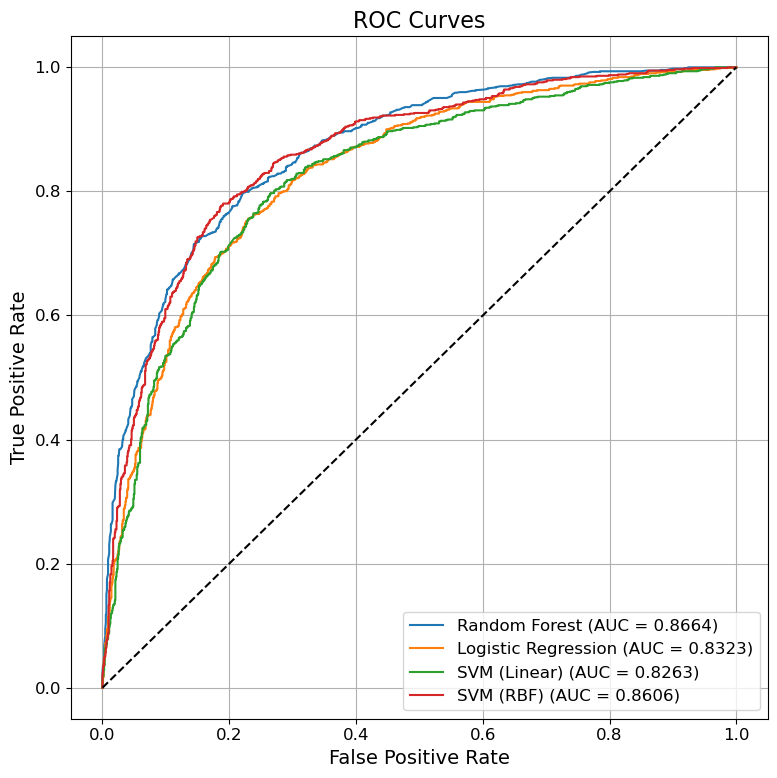

In [69]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

plt.figure(figsize=(8, 8))

# 1. Random Forest
rf_probs = best_rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')

# 2. Logistic Regression
lr_probs = best_lr.predict_proba(X_test_scaled)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')

# 3. SVM (linear)
svm_probs = best_svm.predict_proba(X_test_scaled)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)
auc_svm = auc(fpr_svm, tpr_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (Linear) (AUC = {auc_svm:.4f})')

# 4. SVM (rbf)
svm_rbf_probs = best_svm_rbf.predict_proba(X_test_scaled)[:, 1]
fpr_rbf, tpr_rbf, _ = roc_curve(y_test, svm_rbf_probs)
auc_rbf = auc(fpr_rbf, tpr_rbf)
plt.plot(fpr_rbf, tpr_rbf, label=f'SVM (RBF) (AUC = {auc_rbf:.4f})')

# Plot settings
plt.plot([0, 1], [0, 1], 'k--', label='')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


# plot : PR curve

In [57]:
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


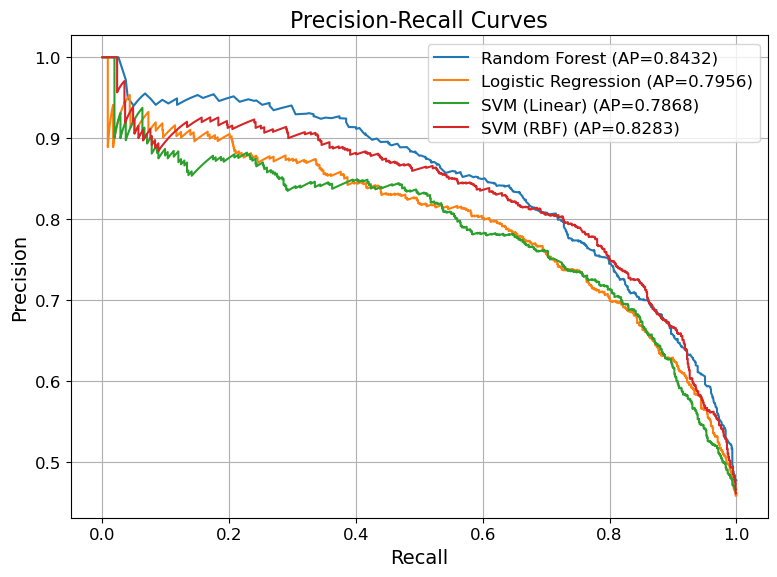

In [60]:

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

plt.figure(figsize=(8, 6))

models = {
    "Random Forest": (best_rf, X_test),
    "Logistic Regression": (best_lr, X_test_scaled),
    "SVM (Linear)": (best_svm, X_test_scaled),
    "SVM (RBF)": (best_svm_rbf, X_test_scaled)
}

# Precision-Recall Curve
for name, (model, X_data) in models.items():
    probs = model.predict_proba(X_data)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap_score = average_precision_score(y_test, probs)
    plt.plot(recall, precision, label=f'{name} (AP={ap_score:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## plot : Calibration curves

Random Forest - Brier Score: 0.1498
Logistic Regression - Brier Score: 0.1675
SVM (Linear) - Brier Score: 0.1734
SVM (RBF) - Brier Score: 0.1517


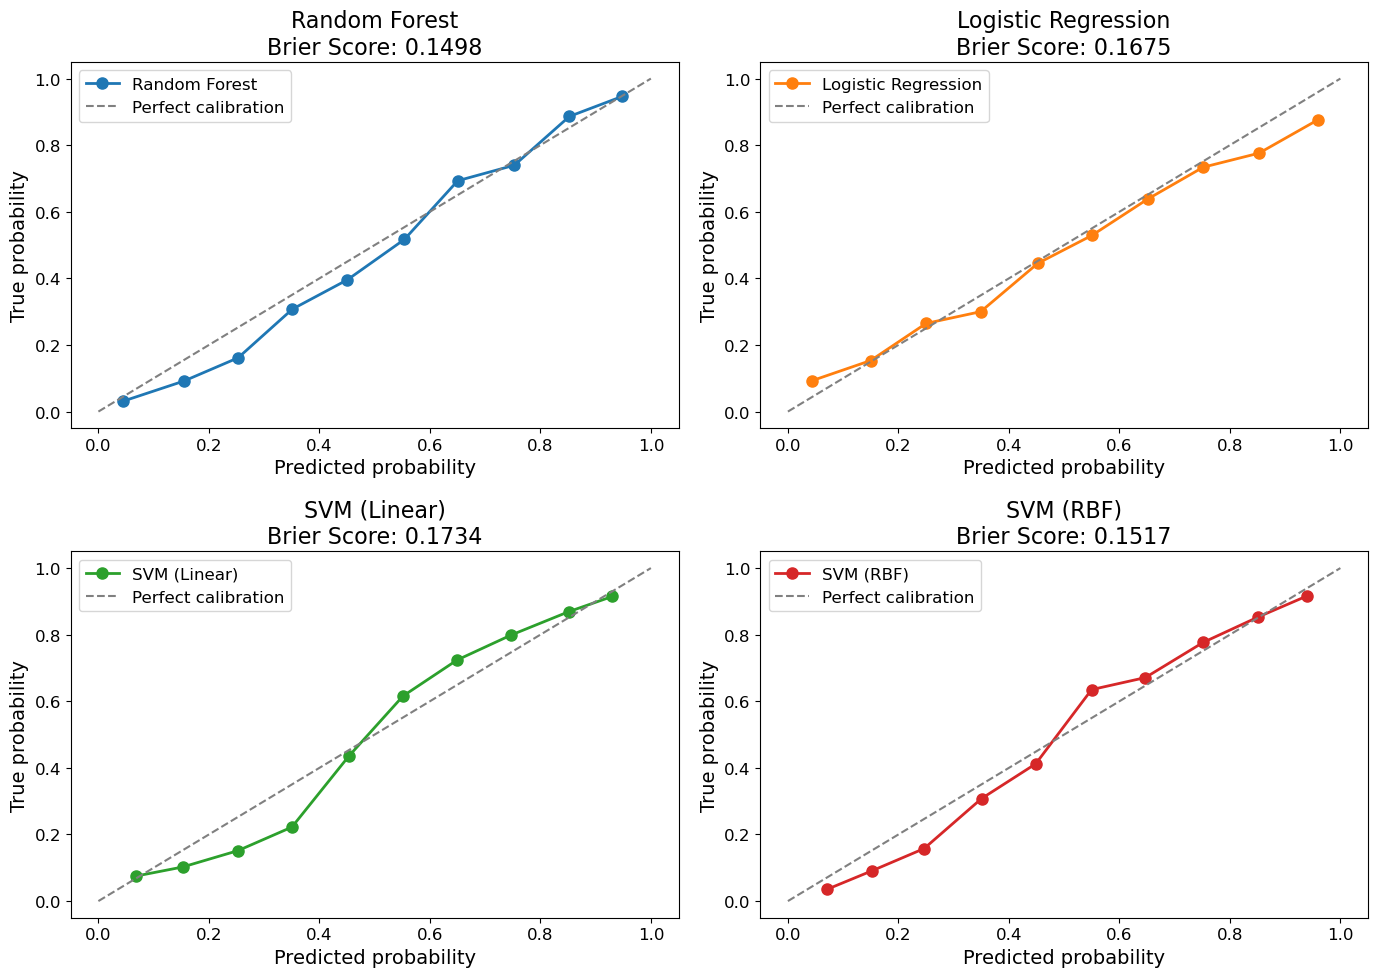

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

colors = {
    "Random Forest": "#1f77b4",
    "Logistic Regression": "#ff7f0e",
    "SVM (Linear)": "#2ca02c",
    "SVM (RBF)": "#d62728"
}

models = {
    "Random Forest": best_rf,
    "Logistic Regression": best_lr,
    "SVM (Linear)": best_svm,
    "SVM (RBF)": best_svm_rbf
}

plt.figure(figsize=(14, 10))

for i, (name, model) in enumerate(models.items(), 1):
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = (model.decision_function(X_test_scaled) - model.decision_function(X_test_scaled).min()) / \
                 (model.decision_function(X_test_scaled).max() - model.decision_function(X_test_scaled).min())

    # Brier Score
    brier = brier_score_loss(y_test, y_prob)
    print(f"{name} - Brier Score: {brier:.4f}")

    # Calibration Curve
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

    plt.subplot(2, 2, i)
    plt.plot(
        prob_pred, prob_true, 
        marker='o', 
        markersize=8,
        linewidth=2,
        color=colors[name], 
        label=f'{name}'
    )
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')

    plt.xlabel("Predicted probability", fontsize=14)
    plt.ylabel("True probability", fontsize=14)
    plt.title(f"{name}\nBrier Score: {brier:.4f}", fontsize=16)
    plt.legend(fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


# RF : conformal prediction

In [66]:
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)  # calib 20%
train_idx, calib_idx = next(sss.split(X_train, y_train))

if hasattr(X_train, "iloc"):
    X_tr  = X_train.iloc[train_idx]
    X_cal = X_train.iloc[calib_idx]
else:
    X_tr  = X_train[train_idx]
    X_cal = X_train[calib_idx]

if hasattr(y_train, "iloc"):
    y_tr  = y_train.iloc[train_idx]
    y_cal = y_train.iloc[calib_idx]
else:
    y_tr  = y_train[train_idx]
    y_cal = y_train[calib_idx]


if "w_train" in globals() and w_train is not None:
    if hasattr(w_train, "iloc"):
        w_tr = w_train.iloc[train_idx]
    else:
        w_tr = w_train[train_idx]
else:
    w_tr = None


if 'w_train' in globals() and w_train is not None:
    w_tr = w_train.iloc[train_idx] if hasattr(w_train, 'iloc') else w_train[train_idx]
else:
    w_tr = None

# fit : RF
best_params = {
    "n_estimators": 100,
    "max_depth": None,
    "n_jobs": 1,
    "random_state": 42,
}
rf_cp = RandomForestClassifier(**best_params)
rf_cp.fit(X_tr, y_tr, sample_weight=w_tr)

# Nonconformity: s(x,y) = 1 - P(y|x)
classes = rf_cp.classes_
idx_neg = int(np.where(classes == 0)[0][0])
idx_pos = int(np.where(classes == 1)[0][0])

proba_cal = rf_cp.predict_proba(X_cal)  # shape (n_cal, 2)
col_idx   = np.where(y_cal == 1, idx_pos, idx_neg)
p_cal_true = proba_cal[np.arange(len(y_cal)), col_idx]
s_cal = 1.0 - p_cal_true

def conformal_quantile(scores, alpha):
    scores = np.asarray(scores)
    n = len(scores)
    k = int(np.ceil((n + 1) * (1 - alpha)))
    k = min(max(k, 1), n)
    return np.partition(scores, k-1)[k-1]

alpha = 0.10
s_cal_pos = s_cal[y_cal == 1]
s_cal_neg = s_cal[y_cal == 0]
q_pos = conformal_quantile(s_cal_pos, alpha)
q_neg = conformal_quantile(s_cal_neg, alpha)

proba_test = rf_cp.predict_proba(X_test)
p1_test = proba_test[:, idx_pos]
p0_test = proba_test[:, idx_neg]

s_pos = 1.0 - p1_test
s_neg = 1.0 - p0_test

n_pos, n_neg = len(s_cal_pos), len(s_cal_neg)
p_pos = (np.sum(s_cal_pos[:, None] >= s_pos[None, :], axis=0) + 1) / (n_pos + 1)
p_neg = (np.sum(s_cal_neg[:, None] >= s_neg[None, :], axis=0) + 1) / (n_neg + 1)

C_sets = []
for a, b in zip(p_neg, p_pos):  # a=neg, b=pos
    lab = []
    if a > alpha: lab.append(0)
    if b > alpha: lab.append(1)
    C_sets.append(lab)

confidence  = 1.0 - np.minimum(p_neg, p_pos)
credibility = np.maximum(p_neg, p_pos)

# summary
contains = np.array([(yt in C) for yt, C in zip(y_test, C_sets)], dtype=float)
coverage    = contains.mean()
set_sizes   = np.array([len(C) for C in C_sets])
avg_setsize = set_sizes.mean()
frac_ambig  = np.mean(set_sizes == 2)

print({
    "alpha": alpha,
    "coverage@95%?": coverage,
    "avg_set_size": float(avg_setsize),
    "frac_ambiguous_sets": float(frac_ambig),
})

# (optional) Outliers
is_ambig = (set_sizes == 2).astype(int)
rank_key = np.lexsort((credibility, -is_ambig))
outlier_candidates_idx = rank_key

{'alpha': 0.1, 'coverage@95%?': 0.9073006724303554, 'avg_set_size': 1.3583093179634966, 'frac_ambiguous_sets': 0.35830931796349663}


In [1]:
import sys, sklearn, numpy, pandas
import tensorflow as tf
import tensorflow_probability as tfp

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("TFP:", tfp.__version__)
print("NumPy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.7.12 | packaged by conda-forge | (default, Oct 26 2021, 05:35:01) [MSC v.1916 64 bit (AMD64)]
TensorFlow: 2.11.0
TFP: 0.18.0
NumPy: 1.21.6
pandas: 1.3.5
scikit-learn: 1.0.2
